   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


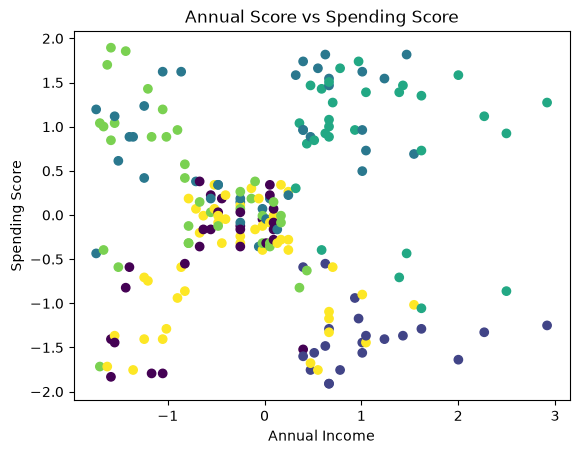

In [11]:
import pandas as pd
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.cluster import KMeans
from kneed import KneeLocator
import matplotlib.pyplot as plt

df = pd.read_csv("../Mall Dataset/Mall_Customers.csv")
print(df.head())
# print(df.isnull().sum())
# print(df.shape)
# print(df.nunique())
# print(df.describe)
le=LabelEncoder()
df["Genre"]=le.fit_transform(df["Genre"])
# print(df["Genre"])

# X features defined
X=df[["Genre","Age","Annual Income (k$)","Spending Score (1-100)"]]

scaler=StandardScaler()
X_trained_scaled=scaler.fit_transform(X)

wcss=[]
k_values=range(1,11)

for k in k_values:
    model=KMeans(
        n_clusters=k,
        random_state=42
    )
    model.fit(X_trained_scaled)
    wcss.append(model.inertia_)
    
knee=KneeLocator(
    k_values,
    wcss,
    curve="convex",
    direction="decreasing"
)
best_k=knee.elbow
model=KMeans(
    n_clusters=best_k,
    random_state=42
)

# print(f"The best k is {knee.elbow}")
labels=model.fit_predict(X_trained_scaled)
plt.scatter(
    X_trained_scaled[:,2],X_trained_scaled[:,3],c=labels
)  
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Annual Score vs Spending Score")
plt.show() 
        



   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(-1)}
0


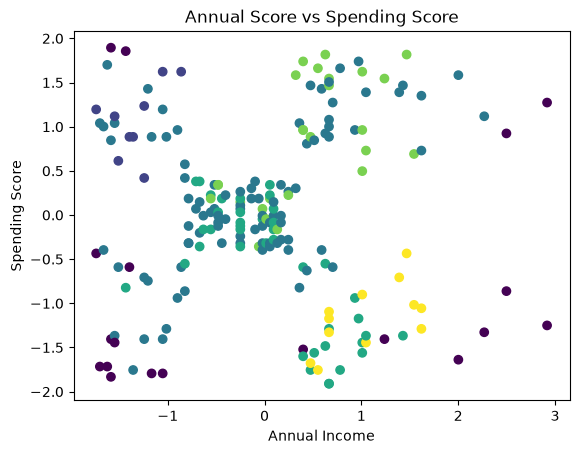

: 

In [ ]:
#DBSCAN

import pandas as pd
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.cluster import KMeans
from kneed import KneeLocator
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

df = pd.read_csv("../Mall Dataset/Mall_Customers.csv")
print(df.head())
# print(df.isnull().sum())
# print(df.shape)
# print(df.nunique())
# print(df.describe)
le=LabelEncoder()
df["Genre"]=le.fit_transform(df["Genre"])
# print(df["Genre"])

# X features defined
X=df[["Genre","Age","Annual Income (k$)","Spending Score (1-100)"]]

scaler=StandardScaler()
X_trained_scaled=scaler.fit_transform(X)

# wcss=[]
# k_values=range(1,11)

# for k in k_values:
#     model=KMeans(
#         n_clusters=k,
#         random_state=42
#     )
#     model.fit(X_trained_scaled)
#     wcss.append(model.inertia_)
    
# knee=KneeLocator(
#     k_values,
#     wcss,
#     curve="convex",
#     direction="decreasing"
# )
# best_k=knee.elbow
# model=KMeans(
#     n_clusters=best_k,
#     random_state=42
# )
model=DBSCAN(
    eps=0.8,
    min_samples=5
)
# print(f"The best k is {knee.elbow}")
labels=model.fit_predict(X_trained_scaled)
print(set(labels))

count=0
if(set(labels)==-1):
        count+=1
print(count)

plt.scatter(
    X_trained_scaled[:,2],X_trained_scaled[:,3],c=labels
)  
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Annual Score vs Spending Score")
plt.show() 

